### LSTM (장기 의존성 학습 모델)
- RNN 구조에서 발생하는 문제를 해결하기 위해 구조룰 변경한 모델
- 기존의 RNN은 학습횟수가 증가하면 과거의 기억을 잃는다.
    - 반복 학습을 하면서 가중치의 변화량이 0에 가까워진다.
    - 손실 함수 -> tanh -> 반복적으로 -1 ~ 1의 가중치으 변화량이 곱해지면서 0에 수렴 (기억 손실)
- LSTM 모델은 반복 학습을 하면서 과거의 기억 중 장기 기억으로 나눠주는 역할
    - 반복 학습을 하면서 tanh()를 중복적으로 실행하면서 0에 가까워짐
    - 장기 기억 tanh()함수를 실행하지 않는다 -> 가중치의 변화를 유지
    - cell 공간에 장기 기억 정보를 전달
    - 게이트로 정보를 선택적으로 보관, 삭제, 츨력


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [5]:
#하나의 함수화를 생각하면서 코드르 작성
#매개변수로 사용할 데이터들에는 어떤 것이 있을까?
#파일의 경로를 지정하는 변수 (read_csv)
file_path='../../csv/AAPL.csv'
#구간(window) 설정 (Dataset)
window=60
#배치 사이즈 지정 (DataLoader)
x_batch=64
y_batch=256
#기여도 (optimizer)
lr =0.001
#반복 학습의 횟수
epochs=20
#은닉층에서의 뉴런(feature)의 수
hidden_cat=64
#layer 설정 값
layer_cnt=1
#train, test 비율
train_ratio=0.8
#은닉층, 셀 구조에서 어떤 부분을 사용할 것인가?
#'h', 'c', 'h_c'
head_type='c'

In [6]:
df=pd.read_csv(file_path)
#결측치 제거 (주식 데이터에서 결측치는 개수가 1개뿐, 결측치가 존재하면 안되는 데이터셋이기 때문에 제거)
df.dropna(inplace=True)

In [7]:
#Date 컬럼을 시계열 데이터로 변환
#그래프 시각화 할떼 x축으로 사용하기 위함
df['Date']=pd.to_datetime(df['Date'])
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.410525,117258400.0
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.389106,43971200.0
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.360548,26432000.0
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.369472,21610400.0
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.380182,18362400.0


In [8]:
#독리브 종속 데이터로 분할
x=df[['Adj Close','Volume']].astype(float).values
y=df[['Adj Close']].astype(float).values

In [9]:
#train, test 데이터셋 분할
X_train,X_test,y_train,y_test=train_test_split(
    x, y, train_size=train_ratio, shuffle=False
)
X_train[-5:]

array([[5.0455521e+01, 2.0321910e+08],
       [4.9966183e+01, 1.5812440e+08],
       [4.9684608e+01, 1.0740940e+08],
       [4.8878670e+01, 1.6277170e+08],
       [4.7721058e+01, 1.3691020e+08]])

In [10]:
#train_test_split()함수와 결과가 같은지 비교
split_idx=int(len(x)*train_ratio)

X_train2=x[:split_idx]
X_train2[-5:]

array([[5.0455521e+01, 2.0321910e+08],
       [4.9966183e+01, 1.5812440e+08],
       [4.9684608e+01, 1.0740940e+08],
       [4.8878670e+01, 1.6277170e+08],
       [4.7721058e+01, 1.3691020e+08]])

### 연습
1. Dataset을 생성 -> 입력 데이터는 array의 형태이며 출려은 tensor의 형태로 구성
    - tensor를 생성하는 과정에서 깊은 복사를 이용한 원본의 데이터를 유지하도록 생성
    - window 값에 따라서 구간을 설정하는 방벙
2. MinMaxScaler를 이용하여 데이터를 스케일링
3. Dataset에 데이터를 입력 (초기에 설정한 window 값 사용)
4. DataLoader를 이용하여 train_dl, test_dl을 생성
    - train DataLoader는 x_batch를 이용
    - test DataLoader는 y_batch를 이용

In [11]:
class windowDS(Dataset):
    def __init__(self, _x, _y, _window):
        self.x=_x
        self.y=_y
        self.window=_window
        self.n=len(_x)-_window

    def __len__(self):
        return max(self.n, 1)
    
    def __getitem__(self,idx):
        x=self.x[idx:idx+self.window]
        y=self.y[idx+self.window]
        #깊은 복사로 tensor 생성
        #일반적으로 얕은 복사를 사용하는 경우가 많음 : 메모리의 사용량 줄이기
        x_tensor=torch.tensor(x, dtype=torch.float32)
        y_tensor=torch.tensor(y, dtype=torch.float32)
        return x_tensor, y_tensor

In [12]:
#스케일링 작업
x_scaler=MinMaxScaler().fit(X_train)
y_scaler=MinMaxScaler().fit(y_train)

X_train_sc=x_scaler.transform(X_train)
X_test_sc=x_scaler.transform(X_test)
y_train_sc=y_scaler.transform(y_train)
y_test_sc=y_scaler.transform(y_test)

In [13]:
#데이터셋 셍성
train_ds=windowDS(X_train_sc,y_train_sc,window)
test_ds=windowDS(X_test_sc,y_test_sc,window)

In [14]:
#DataLoader 생성
train_dl=DataLoader(train_ds, shuffle=True, drop_last=True, batch_size=x_batch)
test_dl=DataLoader(train_ds, shuffle=False, drop_last=False, batch_size=y_batch)

In [15]:
#LSTM 모델 정의
class LSTMModel(nn.Module):
    def __init__(self, 
                input_size, 
                hidden_size=64, 
                num_layers=1, 
                dropout=0.0, 
                bidirectional=False, 
                batch_first=True, 
                head_type='c'
        ):
        super(LSTMModel, self).__init__()

        #LSTM 기본 설정
        self.lstm=nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            bidirectional=bidirectional,
            batch_first=batch_first
        )

        #bidirectional이 True인 out feature의 개수가 2배
        hidden_size=hidden_size * (2 if bidirectional else 1)

        #head type에 땨라서 출력의 feature 개수가 달라진다.
        if head_type in ['h','c']:
        # if (head_type == 'f') | (head_type =='c')
            pass
        elif head_type == 'h_c':
            hidden_size=hidden_size*2
        else:
            print("head_type의 인자의 값을 잘못 입력하였습니다. ('h', 'c', 'h_c')을 써주세요")

        #선형 모델 생성
        self.model=nn.Linear(hidden_size, 1)
        #객체 안의 독립적인 데이터를 저장
        self.head_type=head_type
    
    #순전파 함수 정의
    def forward(self, x):
        #순전파의 예측 값 (RNN 모델에서는 2개, LSTM 모델에서는 3개)
        out, (h_n, c_n) = self.lstm(x)
        #은닉층의 가장 마지막 값 저장
        h_last=h_n[-1]
        c_last=c_n[-1]

        if self.head_type == 'h':
            feat=h_last
        elif self.head_type == 'c':
            feat=c_last
        elif self.head_type == 'h_c':
            feat=torch.cat( [h_last, c_last], dim=-1 )
        
        return self.model(feat)

In [16]:
#모델을 생성
model=LSTMModel(input_size=2, hidden_size=hidden_cat, head_type=head_type)
model

LSTMModel(
  (lstm): LSTM(2, 64, batch_first=True)
  (model): Linear(in_features=64, out_features=1, bias=True)
)

In [17]:
#손실 함수
criterion=nn.MSELoss()
#옵티마이저 설정
optimizer=optim.Adam(model.parameters(),lr=lr)

In [18]:
# 검증 데이터의 loss 값 확인하는 함수 

@torch.no_grad()
def evaluate_mse(dl):
    model.eval()

    total_loss, total_n  = 0.0, 0
    # 데코레이터를 사용하지 않는 경우 with을 이용
    # with torch.no_grad():
    for x, y in dl:
        x = x.float()
        y = y.float()
        pred = model(x)
        loss = criterion(pred, y)
        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
    
    return total_loss / max(total_n, 1)

In [19]:
# 반복 학습 
test_history = []

for epoch in range(epochs):
    model.train()

    total_loss, total_n = 0.0, 0

    for x, y in train_dl:
        x = x.float()
        y = y.float()

        pred = model(x)
        loss = criterion(pred, y)       # 데이터들의 평균 오차 
        optimizer.zero_grad()
        loss.backward()
        # 기울기 발산 방지 
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
    
        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
    
    train_loss = total_loss / max(total_n, 1)

    test_loss = evaluate_mse(test_dl)

    test_history.append(test_loss)

    print(f"Epoch : {epoch + 1}, train_mse : {round(train_loss, 4)},\
           test_mse : {round(test_loss, 4)}")

Epoch : 1, train_mse : 0.0052,           test_mse : 0.0001
Epoch : 2, train_mse : 0.0001,           test_mse : 0.0001
Epoch : 3, train_mse : 0.0001,           test_mse : 0.0001
Epoch : 4, train_mse : 0.0001,           test_mse : 0.0001
Epoch : 5, train_mse : 0.0001,           test_mse : 0.0001
Epoch : 6, train_mse : 0.0001,           test_mse : 0.0001
Epoch : 7, train_mse : 0.0001,           test_mse : 0.0001
Epoch : 8, train_mse : 0.0001,           test_mse : 0.0
Epoch : 9, train_mse : 0.0001,           test_mse : 0.0001
Epoch : 10, train_mse : 0.0001,           test_mse : 0.0
Epoch : 11, train_mse : 0.0001,           test_mse : 0.0
Epoch : 12, train_mse : 0.0,           test_mse : 0.0001
Epoch : 13, train_mse : 0.0001,           test_mse : 0.0
Epoch : 14, train_mse : 0.0,           test_mse : 0.0
Epoch : 15, train_mse : 0.0,           test_mse : 0.0
Epoch : 16, train_mse : 0.0,           test_mse : 0.0
Epoch : 17, train_mse : 0.0,           test_mse : 0.0
Epoch : 18, train_mse : 0.0,

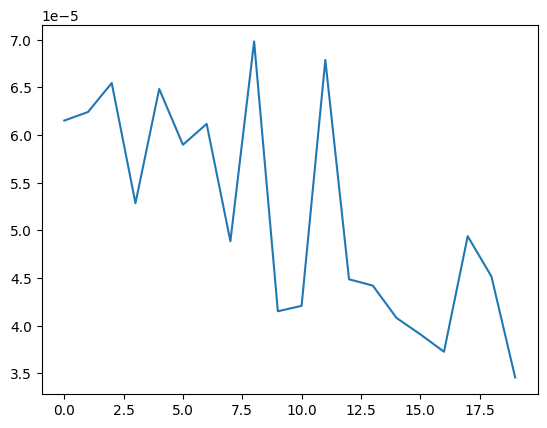

In [20]:
# test_hitory를 그래프 시각화
plt.plot(test_history)
plt.show()

In [21]:
#예측값 생성
model.eval()

preds, trues = [], []

with torch.no_grad():
    for x, y in test_dl:
        x=x.float()
        pred=model(x)
        preds.append(pred)
        trues.append(y)
#tensor 데이터들을 하나로 합쳐주고 차원을 벗겨낸 다음 array로 변환
preds = torch.cat(preds, dim=0).numpy()
trues = torch.cat(trues, dim=0).numpy()

#스케일링 데잍를 원본 데이터로 뱐환
pred_origin = y_scaler.inverse_transform(preds).squeeze(-1)
true_origin=y_scaler.inverse_transform(trues).squeeze(-1)

pred_origin

array([ 0.36084095,  0.34760013,  0.33948636, ..., 50.13702   ,
       49.911617  , 49.487537  ], shape=(7710,), dtype=float32)

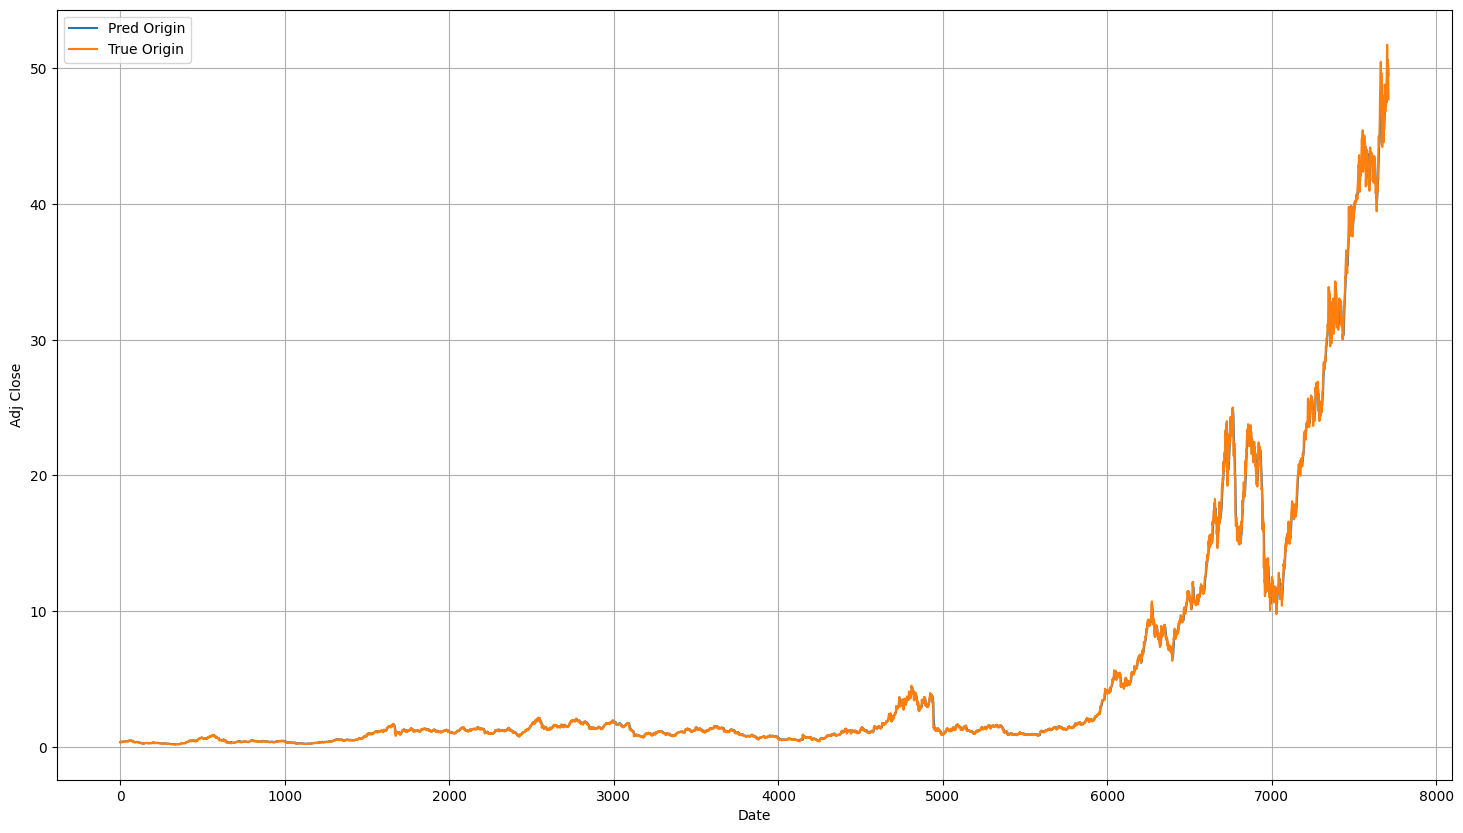

In [22]:
split_idx-int(len(df) * train_ratio)
#test_data에서 window(60일)만큼 지난 61일차의 날짜부터
x_data=df['Date'].values[split_idx + window : ]

plt.figure(figsize=(18,10))
plt.plot(pred_origin, label='Pred Origin')
plt.plot(true_origin, label='True Origin')

plt.legend()
plt.grid()
plt.xlabel('Date')
plt.ylabel('Adj Close')

plt.show()